# DeepLabV3 + MNIST合成データセット セマンティックセグメンテーション

`DeepLabV3_ver7_データ拡張.ipynb` をベースに、データを公開可能な合成データに差し替えたバージョンである。
詳細は README.md を参照。

## このノートブックで行うこと
1. `dataset_generator.py` を呼んで MNIST 合成データセット (train / val / test) を生成する
2. 1ch 入力、11クラス multi-hot セグメンテーションの DeepLabV3-ResNet50 を学習する
3. クラスごとの F1 スコアで評価する
4. ONNX エクスポート (sigmoid は含めず、logit 出力) と検算を行う

## セル構成と実行モード
- **Cell 0〜8**: 必ず最初に実行する (imports / 設定 / データセット / DataLoader / 関数定義)
- **Cell 9〜12**: 学習・PyTorch 評価・ONNX エクスポート (既存の .onnx を使う場合はスキップ可)
- **Cell 13〜15**: ONNX 推論ベースの評価 (既存の .onnx を使う場合はここから実行)

既存の .onnx ファイルを使いたい場合は、Cell 4 の `ONNX_PATH` を該当パスに上書きしてから
Cell 13 以降を実行する。

## ver7 からの主な変更点

| 項目 | ver7 (ERG OFA-SPEC) | 本版 (MNIST合成) |
|---|---|---|
| 入力データ | BMP実データ (180×1024) | 合成画像 (1024×180) `.npy` |
| 入力チャネル | 3ch (RGBにグレースケール複製) | **1ch (グレースケール直接入力)** |
| クラス数 | 3 (背景・ヒス・コーラス) | **11 (背景・数字0〜9)** |
| ラベル形式 | single-label (各ピクセル排他クラス) | **multi-hot (各ピクセル多重所属可)** |
| 損失関数 | CrossEntropyLoss | **BCEWithLogitsLoss** |
| 推論時判定 | `argmax` | **`sigmoid(logits) > 閾値`** |
| 後処理分類 | 4クラス (背景のみ/ヒスのみ/コーラスのみ/両方) | **10次元 multi-label (画像中に存在する数字)** |
| ONNX出力 | logits → 後段で argmax | **logits → 後段で sigmoid + 閾値判定** |

In [1]:
# 使用 GPU を指定する
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

In [2]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
from tqdm import tqdm

# 自前モジュール (同ディレクトリの dataset_generator.py)
import dataset_generator as dg

# ノートブック名を取得 (出力ディレクトリ名に使う)
try:
    import ipynbname
    notebook_filename = ipynbname.name()
    notebook_stem = os.path.splitext(notebook_filename)[0]
except Exception:
    # ipynbname が動かない環境用のフォールバック
    notebook_stem = 'DeepLabV3_MNIST_segmentation'

In [3]:
# ==================== 設定 ====================
date_str = datetime.now().strftime('%Y%m%d')

# データセット出力先 (build_dataset で生成する場所)
DATASET_ROOT = Path('./data_mnist_synthetic')
TRAIN_DATA_DIR = DATASET_ROOT / 'train_val_pool'  # 後で 8:2 分割する
TEST_DATA_DIR = DATASET_ROOT / 'test'             # 汎化評価用

# 学習成果物の出力先
OUTPUTS_DIR = Path('saved_model') / f'{notebook_stem}_outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_VIS_DIR = OUTPUTS_DIR / f'{date_str}_output_visualization'
OUTPUT_VIS_DIR.mkdir(parents=True, exist_ok=True)
print(f'成果物出力先: {OUTPUTS_DIR}')

# ==================== ハイパーパラメータ ====================
NUM_CLASSES = dg.NUM_CLASSES_WITH_BACKGROUND  # 11 (背景 + 数字0〜9)
INPUT_HEIGHT = dg.CANVAS_HEIGHT               # 1024
INPUT_WIDTH = dg.CANVAS_WIDTH                 # 180

# データ生成枚数 (実験規模に応じて調整する)
NUM_TRAIN_VAL_IMAGES = 1000  # train + val の合計 (8:2 で分割する)
NUM_TEST_IMAGES = 250        # 汎化評価用

# 学習設定
BATCH_SIZE = 4
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 推論時のクラス判定閾値 (sigmoid 出力に対する閾値である)
SIGMOID_THRESHOLD = 0.5

# 後処理での「画像中にクラス c が存在する」判定の閾値ピクセル数
PRESENCE_THRESHOLD_PIXELS = 50

# ==================== モデルファイルパス ====================
# 学習で保存する PyTorch best モデルのパス
BEST_MODEL_PATH = OUTPUTS_DIR / f'{date_str}_best_model.pth'

# 学習再開用のチェックポイントパス (日付なし、毎エポック上書きする)。
# このファイルが存在すれば Cell 9 は自動的に「前回の続きから」再開する。
# 新規に学習し直したい場合は、このファイルを手動で削除してから Cell 9 を実行する。
CHECKPOINT_PATH = OUTPUTS_DIR / 'last_checkpoint.pth'

# ONNX モデルのパス。
# 既存の .onnx を使って評価だけ実行したい場合は、ここを直接上書きしてから
# Cell 13 以降を実行する。例:
#     ONNX_PATH = Path('saved_model/DeepLabV3_MNIST_segmentation_outputs/20260601_deeplabv3_mnist.onnx')
ONNX_PATH = OUTPUTS_DIR / f'{date_str}_deeplabv3_mnist.onnx'

print(f'Device: {DEVICE}, Classes: {NUM_CLASSES}, Input: {INPUT_HEIGHT}x{INPUT_WIDTH}')
print(f'ONNX_PATH (Cell 13 以降で使用): {ONNX_PATH}')

成果物出力先: saved_model/DeepLabV3_MNIST_segmentation_outputs
Device: cuda, Classes: 11, Input: 1024x180
ONNX_PATH (Cell 13 以降で使用): saved_model/DeepLabV3_MNIST_segmentation_outputs/20260617_deeplabv3_mnist.onnx


In [4]:
# ==================== データセット生成 (dataset_generator.py を呼ぶ) ====================
# 既存ファイルがある場合は再生成しない (ディスクキャッシュ的に使う)
if not (TRAIN_DATA_DIR / 'images').exists() or \
   len(list((TRAIN_DATA_DIR / 'images').glob('*.npy'))) < NUM_TRAIN_VAL_IMAGES:
    print(f'\nTrain+Val プールを生成する ({NUM_TRAIN_VAL_IMAGES} 枚)...')
    dg.build_dataset(
        TRAIN_DATA_DIR,
        num_images=NUM_TRAIN_VAL_IMAGES,
        mnist_train=True,   # MNIST 訓練分から数字をサンプリングする
        seed=42,
    )
else:
    print(f'既存のデータを再利用する: {TRAIN_DATA_DIR}')

if not (TEST_DATA_DIR / 'images').exists() or \
   len(list((TEST_DATA_DIR / 'images').glob('*.npy'))) < NUM_TEST_IMAGES:
    print(f'\nTest セットを生成する ({NUM_TEST_IMAGES} 枚)...')
    dg.build_dataset(
        TEST_DATA_DIR,
        num_images=NUM_TEST_IMAGES,
        mnist_train=False,  # MNIST テスト分から数字をサンプリングする (汎化評価)
        seed=2026,
    )
else:
    print(f'既存のデータを再利用する: {TEST_DATA_DIR}')

既存のデータを再利用する: data_mnist_synthetic/train_val_pool
既存のデータを再利用する: data_mnist_synthetic/test


In [5]:
# ==================== Dataset クラス ====================
class SyntheticMnistSegmentationDataset(Dataset):
    """build_dataset で保存した (canvas, mask) ペアをロードする Dataset である。

    Returns per __getitem__:
        image: (1, H, W) float32 [0, 1]
        mask:  (11, H, W) float32 {0, 1}
        filename: 元の .npy ファイル名 (ロギング用)
    """

    def __init__(self, data_dir):
        data_dir = Path(data_dir)
        self.images_dir = data_dir / 'images'
        self.masks_dir = data_dir / 'masks'
        self.image_paths = sorted(self.images_dir.glob('*.npy'))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.masks_dir / image_path.name

        # 画像読み込み: (H, W) uint8 → (1, H, W) float32 [0, 1]
        canvas_uint8 = np.load(image_path)
        image_tensor = torch.from_numpy(canvas_uint8.astype(np.float32) / 255.0).unsqueeze(0)

        # マスク読み込み: (11, H, W) uint8 {0, 1} → float32 (BCE 損失は float が必要)
        mask_uint8 = np.load(mask_path)
        mask_tensor = torch.from_numpy(mask_uint8.astype(np.float32))

        return image_tensor, mask_tensor, image_path.name


def collate_pairs(batch):
    images = torch.stack([item[0] for item in batch])
    masks = torch.stack([item[1] for item in batch])
    filenames = [item[2] for item in batch]
    return images, masks, filenames


# ==================== Train / Val 8:2 分割 ====================
full_train_val_dataset = SyntheticMnistSegmentationDataset(TRAIN_DATA_DIR)
total_samples = len(full_train_val_dataset)
val_size = int(total_samples * 0.2)
train_size = total_samples - val_size

# 再現性のため seed を固定する
split_generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    full_train_val_dataset, [train_size, val_size], generator=split_generator
)

test_dataset = SyntheticMnistSegmentationDataset(TEST_DATA_DIR)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pairs
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, collate_fn=collate_pairs
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=collate_pairs
)

# クラス名 (可視化・ログ用、英語のみ。matplotlib の日本語対応が無いため)
class_names = ['BG'] + [f'digit_{i}' for i in range(10)]

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 800, Val: 200, Test: 250


可視化ファイル名: 000542.npy


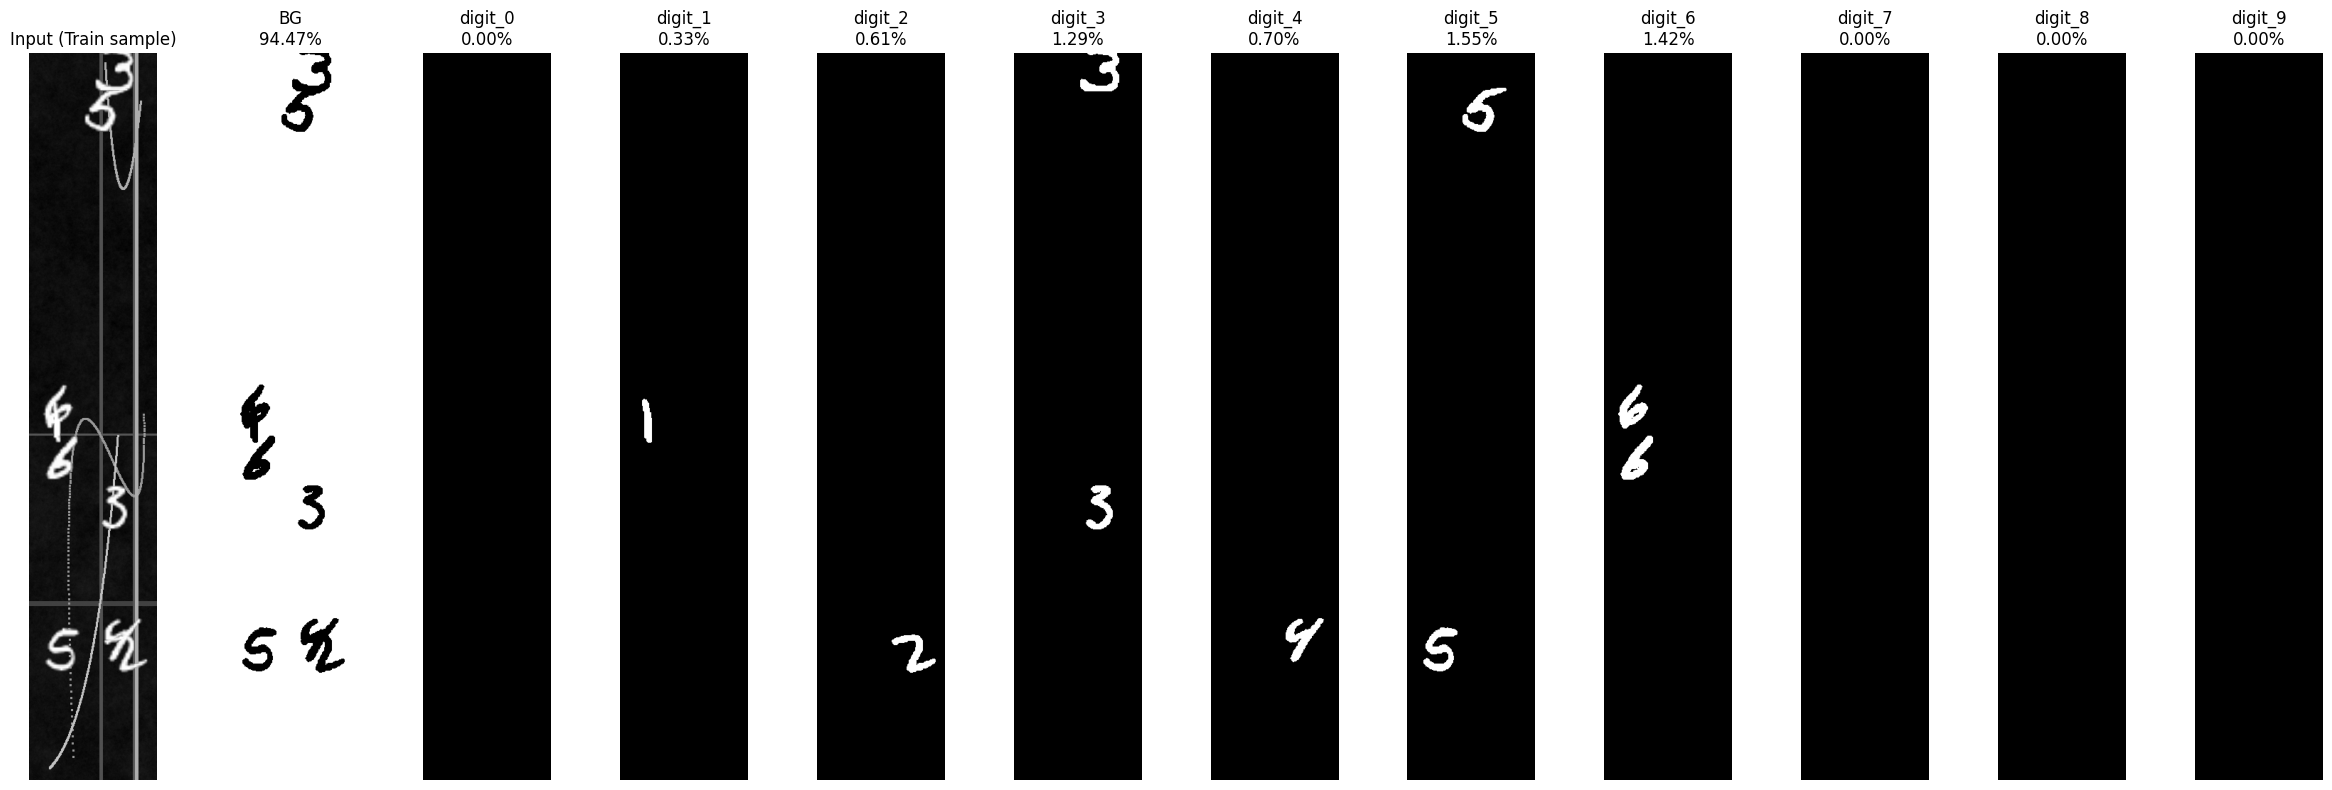

In [6]:
# ==================== データペアを 1 組可視化 (生成データの正しさを目視確認) ====================
# 注: matplotlib のタイトルは英語のみ。日本語フォント設定が無い環境で豆腐になるのを避ける。
def visualize_one_pair(image_tensor, mask_tensor, title_suffix='', save_path=None):
    """画像 1 枚と 11 チャネルのマスクを並べて可視化する。

    Args:
        image_tensor: (1, H, W) float32 [0, 1]
        mask_tensor:  (11, H, W) float32 {0, 1}
        title_suffix: タイトルに付け加える文字列 (例: '(Train)')
        save_path: 保存先パス (None なら保存しない)
    """
    image_np = image_tensor.squeeze(0).numpy()
    mask_np = mask_tensor.numpy()

    # 縦長画像なので、横一列に並べる
    fig, axes = plt.subplots(1, 12, figsize=(24, 8))
    axes[0].imshow(image_np, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Input {title_suffix}')
    axes[0].axis('off')

    for c in range(NUM_CLASSES):
        axes[c + 1].imshow(mask_np[c], cmap='gray', vmin=0, vmax=1)
        coverage_percent = mask_np[c].mean() * 100
        axes[c + 1].set_title(f'{class_names[c]}\n{coverage_percent:.2f}%')
        axes[c + 1].axis('off')

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()


# 訓練セットから 1 ペア取得して可視化する
sample_image, sample_mask, sample_filename = train_dataset[0]
print(f'可視化ファイル名: {sample_filename}')
visualize_one_pair(
    sample_image, sample_mask,
    title_suffix='(Train sample)',
    save_path=OUTPUT_VIS_DIR / f'{date_str}_train_sample_visualization.png',
)

In [7]:
# ==================== 関数定義 ====================
# このセルは「学習を行う場合」「ONNX 推論だけ行う場合」のどちらでも必要である。
# Cell 9 以降にも Cell 13 以降にも依存される関数をここに集約する。

def build_model(num_classes, num_input_channels=1):
    """DeepLabV3-ResNet50 を構築する。

    デフォルトの DeepLabV3-ResNet50 は 3ch 入力なので、最初の conv1 層を
    1ch 入力用に差し替える。weights=None なので事前学習重みは読み込まない。

    Args:
        num_classes: 出力チャネル数 (背景含む)
        num_input_channels: 入力チャネル数 (本タスクでは 1)

    Returns:
        DeepLabV3-ResNet50 モデル (1ch 入力、num_classes 出力)
    """
    model = models.segmentation.deeplabv3_resnet50(
        weights=None,
        weights_backbone=None,
        num_classes=num_classes,
        aux_loss=True,
    )
    original_conv1 = model.backbone.conv1
    model.backbone.conv1 = nn.Conv2d(
        in_channels=num_input_channels,
        out_channels=original_conv1.out_channels,
        kernel_size=original_conv1.kernel_size,
        stride=original_conv1.stride,
        padding=original_conv1.padding,
        bias=(original_conv1.bias is not None),
    )
    return model


def verify_input_output_shape(model, input_height, input_width, num_classes, device='cpu'):
    """モデルの入出力空間サイズが一致することを assert で確認する。

    DeepLabV3 (torchvision 実装) は内部で出力を入力サイズへ bilinear 補間して返すため、
    通常は入出力 HxW が一致する。本コードはこれを前提に masks_resized などの
    補間処理を省略しているので、ここで明示的に検証しておく。

    Args:
        model: 検査対象モデル (.eval() 推奨だが状態は問わない)
        input_height: 期待される入力 H
        input_width:  期待される入力 W
        num_classes:  期待される出力チャネル数
        device:       テスト用ダミー入力を置くデバイス
    """
    model.eval()
    dummy_input = torch.zeros(1, 1, input_height, input_width, device=device)
    with torch.no_grad():
        output_dict = model(dummy_input)
    logits = output_dict['out']
    expected_shape = (1, num_classes, input_height, input_width)
    assert tuple(logits.shape) == expected_shape, (
        f'モデル出力形状が期待と異なる: 期待={expected_shape}, 実際={tuple(logits.shape)}。'
        f'torchvision の DeepLabV3 実装変更の可能性がある。'
    )
    print(f'モデル入出力形状 OK: input={tuple(dummy_input.shape)}, output={tuple(logits.shape)}')


def postprocess_to_presence(prediction_mask, threshold_pixels=PRESENCE_THRESHOLD_PIXELS):
    """(11, H, W) のピクセル予測から、各クラスが画像中に「存在するか」を multi-label で判定する。

    Args:
        prediction_mask: (11, H, W) uint8 - sigmoid 後の閾値判定済みマスク
        threshold_pixels: このピクセル数を超えるとそのクラスは「存在する」と判定する

    Returns:
        (10,) uint8 - 数字 0〜9 の存在フラグ (背景チャネルは除外する)
    """
    # 背景チャネル (index 0) は除外し、数字チャネルのみを対象にする
    presence_flags = np.zeros(dg.NUM_DIGIT_CLASSES, dtype=np.uint8)
    for digit_class in range(dg.NUM_DIGIT_CLASSES):
        channel_index = digit_class + 1
        if prediction_mask[channel_index].sum() >= threshold_pixels:
            presence_flags[digit_class] = 1
    return presence_flags


class DeepLabOutHeadOnly(nn.Module):
    """DeepLabV3 の出力 dict から 'out' (主分岐) のみを取り出すラッパ。

    ONNX エクスポート時に dict 出力をサポートしない実装が多いため、Tensor 単一出力に統一する。
    sigmoid はあえて含めない (後段で閾値を変えられるよう logits のまま出す)。
    """
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x)['out']


def plot_confusion_matrices_grid(matrices, class_names, title, save_path):
    """各クラスの 2x2 混同行列をグリッドに並べて heatmap として保存する。

    multi-label / multi-hot の per-class 2x2 混同行列群を、1 枚の図にまとめて
    PNG 出力する目的の関数である。タイトル・軸ラベルは matplotlib 日本語フォント設定が
    無い環境で豆腐化しないよう、すべて英語のみを使用する。

    Args:
        matrices: 各クラスの 2x2 混同行列のリスト ([[TN, FP], [FN, TP]] 形式)
        class_names: クラス名のリスト (matrices と同じ長さ)
        title: 図全体のタイトル (英語)
        save_path: 保存先パス (.png)
    """
    num_classes_to_plot = len(matrices)
    num_cols = min(num_classes_to_plot, 6)
    num_rows = (num_classes_to_plot + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 2.5))
    # axes を 1 次元配列に揃える (行数・列数によって型が変わるため)
    axes_flat = np.array(axes).reshape(-1) if num_rows * num_cols > 1 else np.array([axes])

    for index, (cm, cn) in enumerate(zip(matrices, class_names)):
        ax = axes_flat[index]
        ax.imshow(cm, cmap='Blues')
        # セルに数値を書き込む。背景の濃淡に応じて文字色を反転する。
        cm_max = cm.max() if cm.max() > 0 else 1
        for row in range(2):
            for col in range(2):
                value = int(cm[row, col])
                text_color = 'white' if value > cm_max / 2 else 'black'
                ax.text(col, row, str(value), ha='center', va='center', color=text_color)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred 0', 'Pred 1'])
        ax.set_yticklabels(['True 0', 'True 1'])
        ax.set_title(cn)
    # 余ったサブプロットは非表示にする
    for unused_index in range(num_classes_to_plot, len(axes_flat)):
        axes_flat[unused_index].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()

モデル入出力形状 OK: input=(1, 1, 1024, 180), output=(1, 11, 1024, 180)

訓練データのクラス分布を計算中...
チャネル別 positive 比率:
  BG:  141078277 px (95.6748%)
  digit_0:     759270 px (0.5149%)
  digit_1:     421234 px (0.2857%)
  digit_2:     748777 px (0.5078%)
  digit_3:     770058 px (0.5222%)
  digit_4:     619344 px (0.4200%)
  digit_5:     595862 px (0.4041%)
  digit_6:     685158 px (0.4647%)
  digit_7:     551325 px (0.3739%)
  digit_8:     759031 px (0.5148%)
  digit_9:     621823 px (0.4217%)

pos_weight (per-class): [4.52069811e-02 1.93207594e+02 3.49057213e+02 1.95929126e+02
 1.90486875e+02 2.37084166e+02 2.46466695e+02 2.14214593e+02
 2.66457489e+02 1.93268745e+02 2.36135005e+02]

チェックポイント発見、前回の続きから再開する: saved_model/DeepLabV3_MNIST_segmentation_outputs/last_checkpoint.pth
  完了済みエポック数: 10
  次のエポック: 11 / 100


Epoch 11/100: 100%|████████████████████████| 200/200 [12:41<00:00,  3.81s/it]


Epoch 11: Loss=0.0405, Val Macro-F1=0.5259
  Per-class F1: ['0.987', '0.608', '0.419', '0.598', '0.445', '0.518', '0.446', '0.520', '0.476', '0.396', '0.372']


Epoch 12/100: 100%|████████████████████████| 200/200 [12:56<00:00,  3.88s/it]


Epoch 12: Loss=0.0396, Val Macro-F1=0.5418
  Per-class F1: ['0.988', '0.714', '0.321', '0.680', '0.454', '0.467', '0.397', '0.685', '0.428', '0.459', '0.368']


...

Epoch 98: Loss=0.0078, Val Macro-F1=0.8026
  Per-class F1: ['0.995', '0.826', '0.785', '0.781', '0.797', '0.779', '0.777', '0.790', '0.777', '0.779', '0.743']


Epoch 99/100: 100%|████████████████████████| 200/200 [19:30<00:00,  5.85s/it]


Epoch 99: Loss=0.0080, Val Macro-F1=0.8049
  Per-class F1: ['0.995', '0.836', '0.780', '0.797', '0.816', '0.783', '0.749', '0.796', '0.794', '0.767', '0.742']


Epoch 100/100: 100%|███████████████████████| 200/200 [19:44<00:00,  5.92s/it]


Epoch 100: Loss=0.0195, Val Macro-F1=0.6930
  Per-class F1: ['0.994', '0.826', '0.635', '0.592', '0.791', '0.400', '0.580', '0.759', '0.667', '0.758', '0.621']


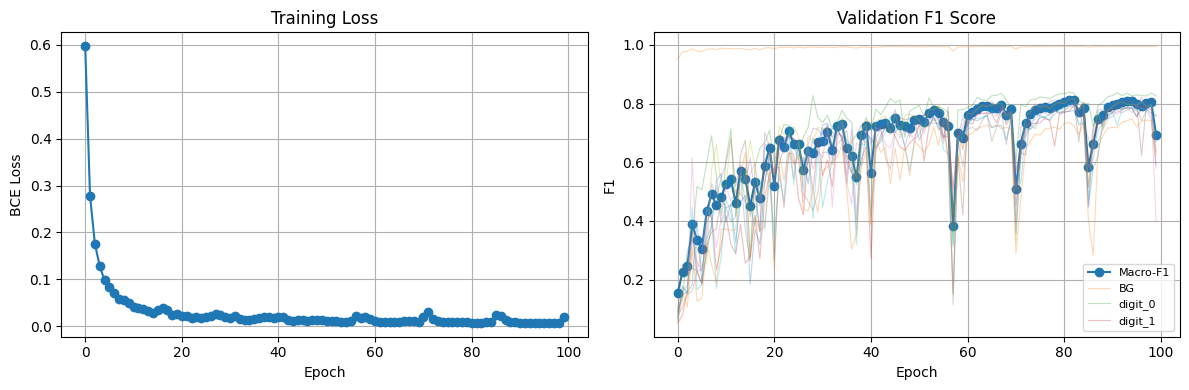

In [18]:
# ==================== 学習 ====================
# 既存の .onnx を使って評価だけ行いたい場合は、このセル〜Cell 12 をスキップして
# Cell 13 から実行する。

# ---------- モデル構築 + 入出力形状の確認 ----------
model = build_model(NUM_CLASSES, num_input_channels=1).to(DEVICE)
verify_input_output_shape(model, INPUT_HEIGHT, INPUT_WIDTH, NUM_CLASSES, device=DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ---------- クラス重み (BCE 用 pos_weight) を計算する ----------
# multi-hot ラベルでは各チャネル独立な二値分類なので、チャネルごとに pos/neg 比を計算する。
# pos_weight[c] = (negative pixel 数) / (positive pixel 数)
print('\n訓練データのクラス分布を計算中...')
positive_count_per_channel = np.zeros(NUM_CLASSES, dtype=np.int64)
total_pixel_count = 0
for idx in range(len(train_dataset)):
    _, mask_tensor, _ = train_dataset[idx]
    mask_np = mask_tensor.numpy()
    positive_count_per_channel += mask_np.reshape(NUM_CLASSES, -1).sum(axis=1).astype(np.int64)
    total_pixel_count += mask_np.shape[1] * mask_np.shape[2]

print('チャネル別 positive 比率:')
for c in range(NUM_CLASSES):
    ratio = positive_count_per_channel[c] / total_pixel_count
    print(f'  {class_names[c]}: {positive_count_per_channel[c]:>10d} px ({ratio*100:.4f}%)')

# pos_weight: positive が少ないチャネルほど大きな重みになる
negative_count_per_channel = total_pixel_count - positive_count_per_channel
positive_count_safe = np.maximum(positive_count_per_channel, 1)  # 0 除算を回避する
pos_weight = negative_count_per_channel / positive_count_safe
# 注: BCEWithLogitsLoss は (B, C, H, W) 形式のテンソルに対して、
# pos_weight を末尾次元から自動ブロードキャストしようとする。クラス次元 (dim=1) に
# 効かせるためには (1, C, 1, 1) の形状にリシェイプして渡す必要がある。
pos_weight_tensor = torch.from_numpy(
    pos_weight.astype(np.float32)
).view(1, NUM_CLASSES, 1, 1).to(DEVICE)
print(f'\npos_weight (per-class): {pos_weight}')

# ---------- 損失関数 ----------
# モデル出力は (B, 11, H, W) の logits。マスクも (B, 11, H, W) の {0, 1} float で
# 入出力 HxW が一致するため、interpolate は不要 (Cell 8 の assert で確認済み)。
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# ---------- 学習再開判定 ----------
# CHECKPOINT_PATH が存在する場合は前回の続きから再開する。
# 保存している全状態 (モデル重み、Adam の慣性、エポック番号、学習履歴) を復元することで、
# 中断前と区別できない結果になることを目指す。
if CHECKPOINT_PATH.exists():
    print(f'\nチェックポイント発見、前回の続きから再開する: {CHECKPOINT_PATH}')
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # 'epoch' は「完了済みエポック番号 (0 始まり)」として保存している。
    # 次に走らせるのは completed_epoch + 1 番目のエポックである。
    start_epoch = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_macro_f1_scores = checkpoint['val_macro_f1_scores']
    val_per_class_f1_history = checkpoint['val_per_class_f1_history']
    best_val_macro_f1 = checkpoint['best_val_macro_f1']
    print(f'  完了済みエポック数: {checkpoint["epoch"]+1}')
    print(f'  次のエポック: {start_epoch+1} / {NUM_EPOCHS}')
    if start_epoch >= NUM_EPOCHS:
        print(f'  → 学習はすでに完了済みである。学習ループはスキップされる。')
else:
    print('\n新規学習を開始する')
    start_epoch = 0
    train_losses = []
    val_macro_f1_scores = []
    val_per_class_f1_history = []
    best_val_macro_f1 = -1.0

# ---------- 学習ループ ----------
for epoch in range(start_epoch, NUM_EPOCHS):
    # ---------- Training ----------
    model.train()
    epoch_loss_sum = 0.0
    for images, masks, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)['out']  # (B, 11, H, W)、入力と同じ HxW
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        epoch_loss_sum += loss.item()
    average_loss = epoch_loss_sum / len(train_loader)
    train_losses.append(average_loss)

    # ---------- Validation ----------
    model.eval()
    all_ground_truth = [[] for _ in range(NUM_CLASSES)]
    all_predictions = [[] for _ in range(NUM_CLASSES)]
    with torch.no_grad():
        for images, masks, _ in val_loader:
            images = images.to(DEVICE)
            logits = model(images)['out']  # 入力と同じ HxW
            predictions = (torch.sigmoid(logits) > SIGMOID_THRESHOLD).cpu().numpy().astype(np.uint8)
            ground_truth = masks.numpy().astype(np.uint8)
            for c in range(NUM_CLASSES):
                all_ground_truth[c].append(ground_truth[:, c].flatten())
                all_predictions[c].append(predictions[:, c].flatten())

    per_class_f1 = []
    for c in range(NUM_CLASSES):
        y_true_c = np.concatenate(all_ground_truth[c])
        y_pred_c = np.concatenate(all_predictions[c])
        f1_c = f1_score(y_true_c, y_pred_c, zero_division=0)
        per_class_f1.append(f1_c)
    val_per_class_f1_history.append(per_class_f1)
    macro_f1 = float(np.mean(per_class_f1))
    val_macro_f1_scores.append(macro_f1)

    print(f'Epoch {epoch+1}: Loss={average_loss:.4f}, Val Macro-F1={macro_f1:.4f}')
    print(f'  Per-class F1: {[f"{f:.3f}" for f in per_class_f1]}')

    # ベストモデル更新時のみ best_model.pth を保存する (推論用)
    if macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = macro_f1
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    # 毎エポックの最後にチェックポイントを保存する (再開用)。
    # 'epoch' は「完了したエポック番号」として保存する。
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_macro_f1_scores': val_macro_f1_scores,
        'val_per_class_f1_history': val_per_class_f1_history,
        'best_val_macro_f1': best_val_macro_f1,
    }, CHECKPOINT_PATH)

# ---------- 学習曲線プロット (タイトル・凡例は英語のみ) ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].grid(True)

axes[1].plot(val_macro_f1_scores, marker='o', label='Macro-F1')
per_class_f1_array = np.array(val_per_class_f1_history)
for c in range(NUM_CLASSES):
    axes[1].plot(per_class_f1_array[:, c], alpha=0.3, linewidth=0.8,
                 label=f'{class_names[c]}' if c < 3 else None)
axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].grid(True)
axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_VIS_DIR / f'{date_str}_training_curves.png')
plt.show()


===== Test セグメンテーション評価 (per-class) =====
Class           F1   Precision    Recall
BG           0.995       1.000     0.991
digit_0      0.830       0.714     0.990
digit_1      0.806       0.718     0.920
digit_2      0.809       0.695     0.968
digit_3      0.802       0.675     0.986
digit_4      0.788       0.681     0.934
digit_5      0.778       0.663     0.942
digit_6      0.823       0.707     0.983
digit_7      0.801       0.689     0.957
digit_8      0.797       0.677     0.970
digit_9      0.750       0.611     0.969

----- 混同行列 (per-class、ピクセル単位) -----
Class               TN        FP        FN        TP
BG             2041858      8094    397899  43632149
digit_0       45721525    101798      2557    254120
digit_1       45891113     50121     11157    127609
digit_2       45728394    104816      7927    238863
digit_3       45759827    102895      3130    214148
digit_4       45788190     88878     13294    189638
digit_5       45800765     90472     10885    177878
digit

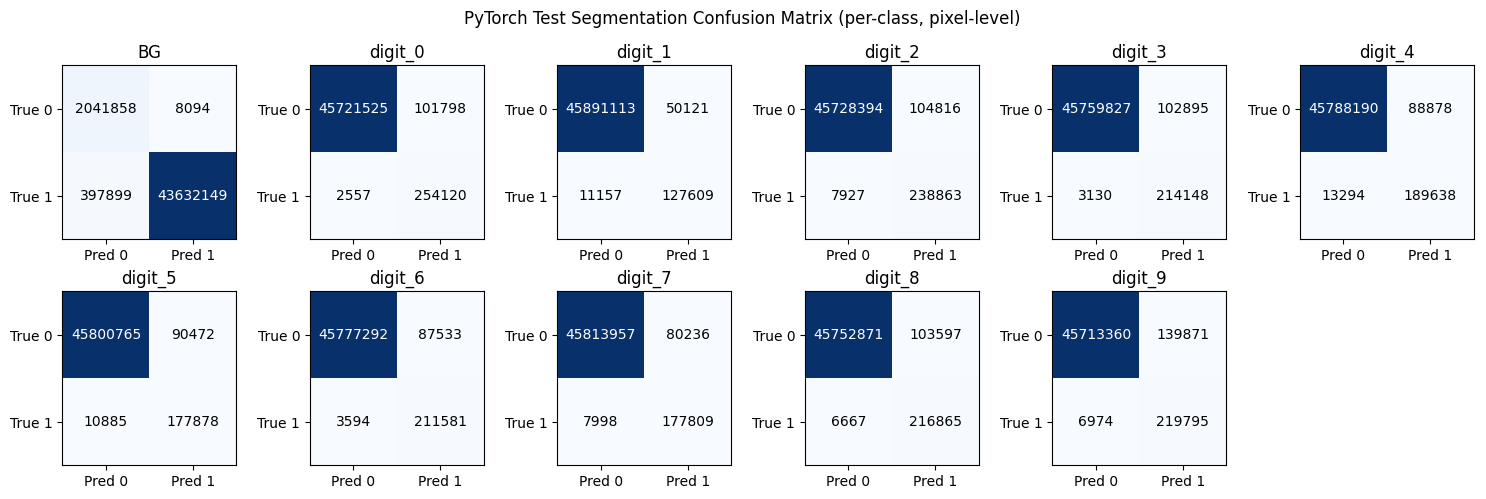

In [19]:
# ==================== セグメンテーション評価 (test_loader, per-class F1) ====================
# best モデルをロードする
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_ground_truth = [[] for _ in range(NUM_CLASSES)]
all_predictions = [[] for _ in range(NUM_CLASSES)]
with torch.no_grad():
    for images, masks, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)['out']  # 入力と同じ HxW
        predictions = (torch.sigmoid(logits) > SIGMOID_THRESHOLD).cpu().numpy().astype(np.uint8)
        ground_truth = masks.numpy().astype(np.uint8)
        for c in range(NUM_CLASSES):
            all_ground_truth[c].append(ground_truth[:, c].flatten())
            all_predictions[c].append(predictions[:, c].flatten())

print('\n===== Test セグメンテーション評価 (per-class) =====')
print(f'{"Class":<10}{"F1":>8}{"Precision":>12}{"Recall":>10}')
for c in range(NUM_CLASSES):
    y_true_c = np.concatenate(all_ground_truth[c])
    y_pred_c = np.concatenate(all_predictions[c])
    f1_c = f1_score(y_true_c, y_pred_c, zero_division=0)
    precision_c = precision_score(y_true_c, y_pred_c, zero_division=0)
    recall_c = recall_score(y_true_c, y_pred_c, zero_division=0)
    print(f'{class_names[c]:<10}{f1_c:>8.3f}{precision_c:>12.3f}{recall_c:>10.3f}')

# ---------- 混同行列 (per-class、ピクセル単位) ----------
# multi-hot なので各クラス独立に 2x2 を出す。labels=[0, 1] でクラスが全 0 でも shape を保証する。
print('\n----- 混同行列 (per-class、ピクセル単位) -----')
print(f'{"Class":<10}{"TN":>12}{"FP":>10}{"FN":>10}{"TP":>10}')
confusion_matrices_pytorch_seg = []
for c in range(NUM_CLASSES):
    y_true_c = np.concatenate(all_ground_truth[c])
    y_pred_c = np.concatenate(all_predictions[c])
    cm = confusion_matrix(y_true_c, y_pred_c, labels=[0, 1])
    confusion_matrices_pytorch_seg.append(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f'{class_names[c]:<10}{tn:>12d}{fp:>10d}{fn:>10d}{tp:>10d}')

# heatmap で保存する (英語タイトルのみ)
plot_confusion_matrices_grid(
    confusion_matrices_pytorch_seg,
    class_names,
    title='PyTorch Test Segmentation Confusion Matrix (per-class, pixel-level)',
    save_path=OUTPUT_VIS_DIR / f'{date_str}_confusion_matrix_pytorch_segmentation.png',
)


===== Test 分類後処理評価 (画像中に各数字が存在するかの multi-label 判定) =====
Digit         F1   Precision    Recall      GT支持
digit_0     0.947       0.899     1.000       124
digit_1     0.934       0.888     0.985       137
digit_2     0.911       0.837     1.000       123
digit_3     0.881       0.787     1.000       118
digit_4     0.947       0.913     0.984       128
digit_5     0.907       0.842     0.982       114
digit_6     0.934       0.876     1.000       120
digit_7     0.903       0.823     1.000       121
digit_8     0.887       0.797     1.000       114
digit_9     0.880       0.795     0.985       134

Macro-F1 (presence): 0.9131

----- 混同行列 (per-digit、画像単位) -----
Digit      TN   FP   FN   TP
digit_0    112   14    0  124
digit_1     96   17    2  135
digit_2    103   24    0  123
digit_3    100   32    0  118
digit_4    110   12    2  126
digit_5    115   21    2  112
digit_6    113   17    0  120
digit_7    103   26    0  121
digit_8    107   29    0  114
digit_9     82   34    2  132


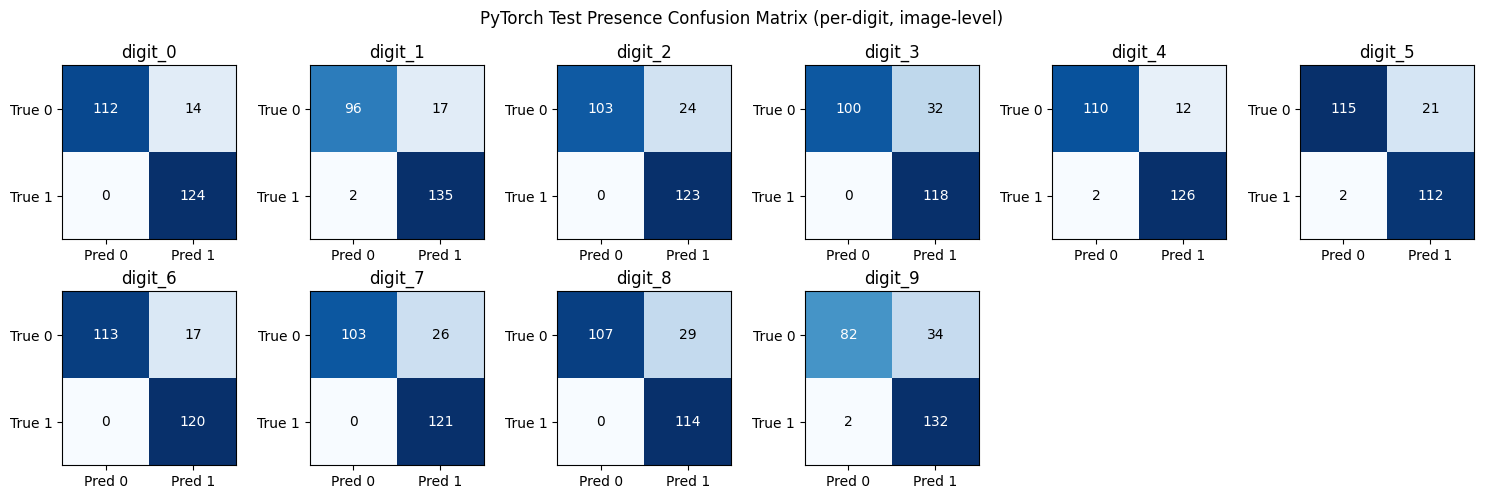

In [20]:
# ==================== 分類後処理評価 (test_loader, 画像中に存在する数字 multi-label 判定) ====================
all_gt_presence = []
all_pred_presence = []
with torch.no_grad():
    for images, masks, _ in test_loader:
        images = images.to(DEVICE)
        logits = model(images)['out']
        prediction_mask = (torch.sigmoid(logits) > SIGMOID_THRESHOLD).cpu().numpy().astype(np.uint8)
        ground_truth_mask = masks.numpy().astype(np.uint8)

        # バッチ次元 (=1) を外して 1 サンプルずつ処理する
        gt_presence = postprocess_to_presence(ground_truth_mask[0])
        pred_presence = postprocess_to_presence(prediction_mask[0])
        all_gt_presence.append(gt_presence)
        all_pred_presence.append(pred_presence)

ground_truth_presence_array = np.stack(all_gt_presence, axis=0)  # (N, 10)
prediction_presence_array = np.stack(all_pred_presence, axis=0)  # (N, 10)

print('\n===== Test 分類後処理評価 (画像中に各数字が存在するかの multi-label 判定) =====')
print(f'{"Digit":<8}{"F1":>8}{"Precision":>12}{"Recall":>10}{"GT支持":>10}')
for digit_class in range(dg.NUM_DIGIT_CLASSES):
    y_true = ground_truth_presence_array[:, digit_class]
    y_pred = prediction_presence_array[:, digit_class]
    f1_d = f1_score(y_true, y_pred, zero_division=0)
    precision_d = precision_score(y_true, y_pred, zero_division=0)
    recall_d = recall_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())
    print(f'digit_{digit_class:<3}{f1_d:>8.3f}{precision_d:>12.3f}{recall_d:>10.3f}{support:>10d}')

macro_f1_presence = f1_score(
    ground_truth_presence_array, prediction_presence_array,
    average='macro', zero_division=0
)
print(f'\nMacro-F1 (presence): {macro_f1_presence:.4f}')

# ---------- 混同行列 (per-digit、画像単位) ----------
print('\n----- 混同行列 (per-digit、画像単位) -----')
print(f'{"Digit":<8}{"TN":>5}{"FP":>5}{"FN":>5}{"TP":>5}')
confusion_matrices_pytorch_presence = []
for digit_class in range(dg.NUM_DIGIT_CLASSES):
    y_true = ground_truth_presence_array[:, digit_class]
    y_pred = prediction_presence_array[:, digit_class]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_matrices_pytorch_presence.append(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f'digit_{digit_class:<3}{tn:>5d}{fp:>5d}{fn:>5d}{tp:>5d}')

# heatmap で保存する (英語タイトルのみ)
digit_only_names = [f'digit_{i}' for i in range(dg.NUM_DIGIT_CLASSES)]
plot_confusion_matrices_grid(
    confusion_matrices_pytorch_presence,
    digit_only_names,
    title='PyTorch Test Presence Confusion Matrix (per-digit, image-level)',
    save_path=OUTPUT_VIS_DIR / f'{date_str}_confusion_matrix_pytorch_presence.png',
)

## メモ
epoch=10回では：
- ピクセル単位での推論はFPが多いが、検出の面ではMacro F1=0.7程度と、ぎりぎり実用可能な値である。
- 学習に時間がかかるのでepochを多く回せていないが、epoch数を増やす必要がある。

In [21]:
# ==================== ONNX エクスポート (sigmoid は含めない) ====================
# DRP-AI Translator 連携を想定して opset_version=12 で固定する。
import onnx
import onnxruntime as ort

# best モデルを再ロードしてエクスポート用に準備する
model_for_export = build_model(NUM_CLASSES, num_input_channels=1)
model_for_export.load_state_dict(torch.load(BEST_MODEL_PATH, map_location='cpu'))
model_for_export.eval()

wrapped_model = DeepLabOutHeadOnly(model_for_export)
wrapped_model.eval()

dummy_input = torch.randn(1, 1, INPUT_HEIGHT, INPUT_WIDTH, dtype=torch.float32)
torch.onnx.export(
    wrapped_model,
    dummy_input,
    str(ONNX_PATH),
    opset_version=12,
    export_params=True,
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    input_names=['input'],
    output_names=['logits'],  # 名前を 'logits' にして sigmoid 未適用であることを明示する
    dynamic_axes=None,
)
print(f'ONNX エクスポート完了: {ONNX_PATH}')

onnx.checker.check_model(onnx.load(str(ONNX_PATH)))
print('ONNX モデル検証: OK')

ONNX エクスポート完了: saved_model/DeepLabV3_MNIST_segmentation_outputs/20260617_deeplabv3_mnist.onnx
ONNX モデル検証: OK


In [22]:
# ==================== ONNX 推論 (test_loader 全件) ====================
# 既存の .onnx を使って評価だけ行う場合、このセルから実行できる。
# 前提として Cell 0〜8 (imports / 設定 / DataLoader / 関数定義) を実行済みであり、
# Cell 4 の ONNX_PATH が読み込みたい .onnx を指していること。
import onnx
import onnxruntime as ort

ort_session = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
input_name = ort_session.get_inputs()[0].name
input_shape_metadata = ort_session.get_inputs()[0].shape
output_shape_metadata = ort_session.get_outputs()[0].shape
print(f'ONNX 入力名: {input_name}, 入力形状メタデータ: {input_shape_metadata}')
print(f'ONNX 出力形状メタデータ: {output_shape_metadata}')

# ONNX 推論結果と GT を蓄積する
onnx_all_gt = [[] for _ in range(NUM_CLASSES)]
onnx_all_pred = [[] for _ in range(NUM_CLASSES)]
onnx_all_gt_presence = []
onnx_all_pred_presence = []
first_sample_for_visualization = None  # Cell 14 で 1 ペア可視化するため保持する

for sample_index, (images, masks, filenames) in enumerate(test_loader):
    image_numpy = images.numpy().astype(np.float32)
    logits_onnx = ort_session.run(None, {input_name: image_numpy})[0]  # (1, 11, H, W)
    prediction_mask = (1.0 / (1.0 + np.exp(-logits_onnx)) > SIGMOID_THRESHOLD).astype(np.uint8)
    ground_truth_mask = masks.numpy().astype(np.uint8)

    for c in range(NUM_CLASSES):
        onnx_all_gt[c].append(ground_truth_mask[:, c].flatten())
        onnx_all_pred[c].append(prediction_mask[:, c].flatten())

    onnx_all_gt_presence.append(postprocess_to_presence(ground_truth_mask[0]))
    onnx_all_pred_presence.append(postprocess_to_presence(prediction_mask[0]))

    if first_sample_for_visualization is None:
        first_sample_for_visualization = (
            images[0],                                           # (1, H, W) float32 [0, 1]
            masks[0],                                            # (11, H, W) float32
            torch.from_numpy(prediction_mask[0]).float(),        # (11, H, W) float32
            filenames[0],
        )

print(f'ONNX 推論完了: {len(test_loader)} サンプル')

ONNX 入力名: input, 入力形状メタデータ: [1, 1, 1024, 180]
ONNX 出力形状メタデータ: [1, 11, 1024, 180]
ONNX 推論完了: 250 サンプル


可視化対象: 000000.npy


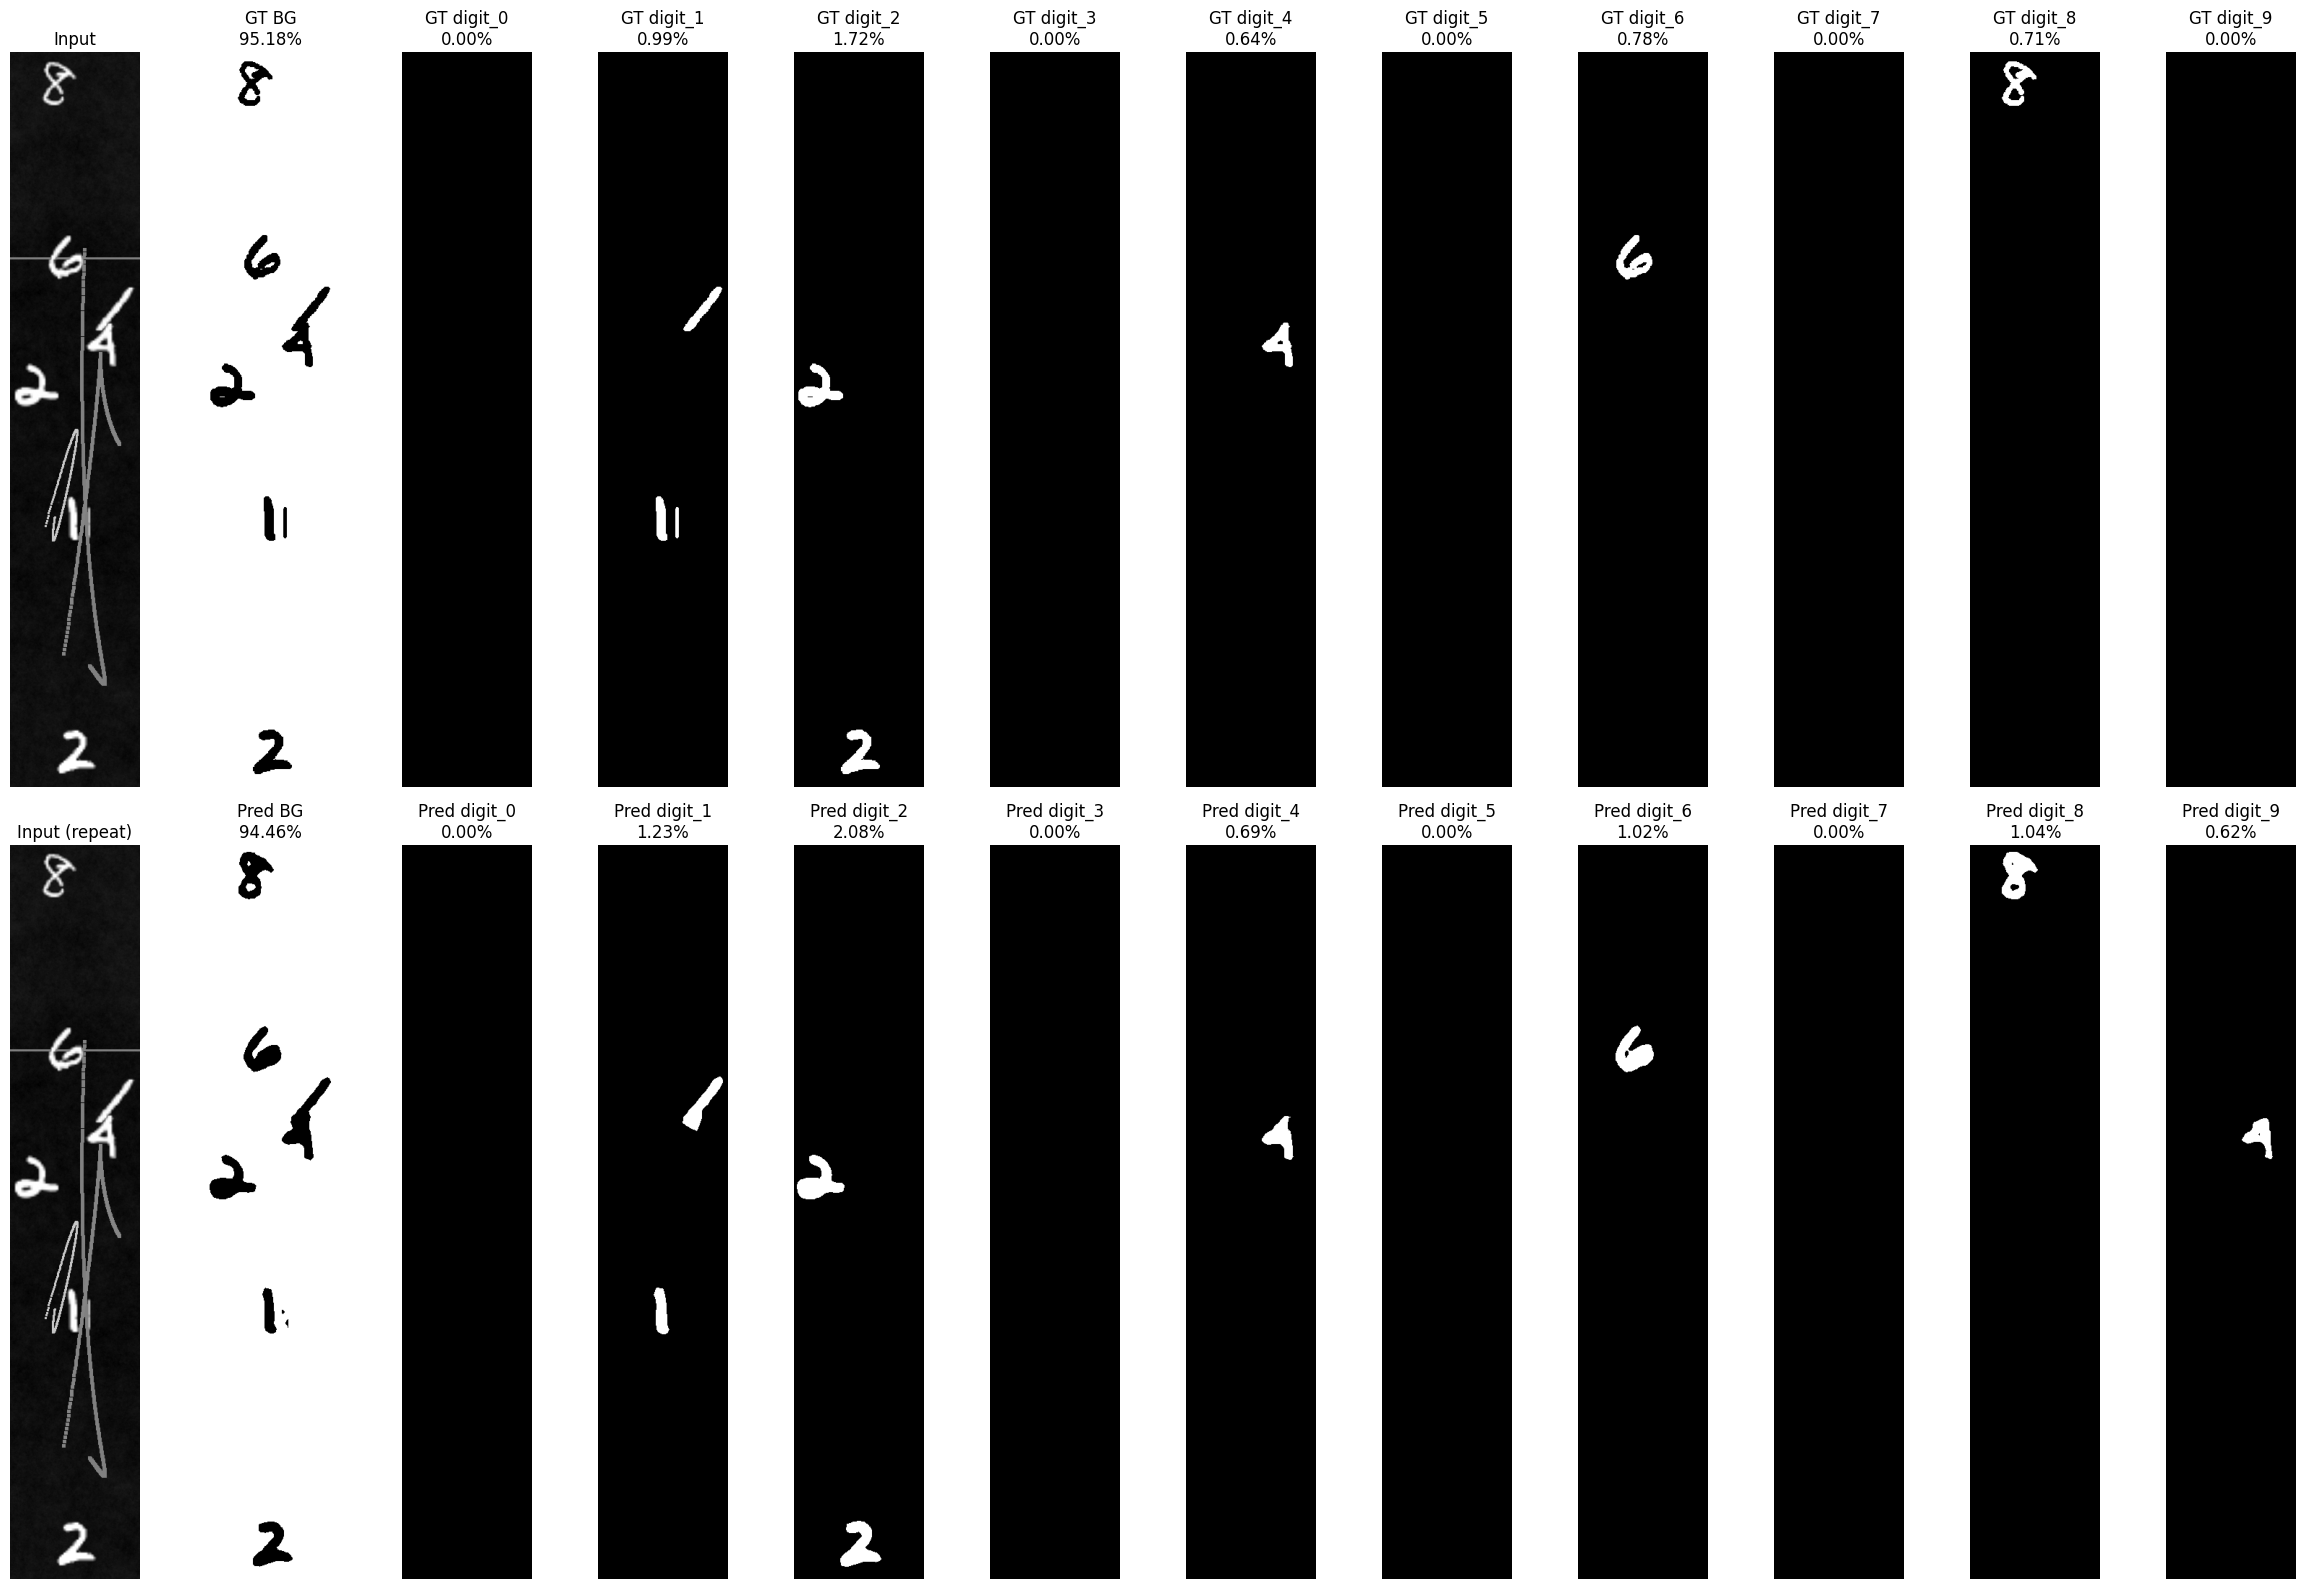

In [23]:
# ==================== ONNX 推論結果の 1 ペア可視化 (GT と Pred を上下に並べる) ====================
# 注: タイトルは全て英語のみ (matplotlib 日本語フォント設定が無い環境用)
sample_image, sample_gt_mask, sample_pred_mask, sample_filename = first_sample_for_visualization
print(f'可視化対象: {sample_filename}')

image_np = sample_image.squeeze(0).numpy()
gt_np = sample_gt_mask.numpy()
pred_np = sample_pred_mask.numpy()

fig, axes = plt.subplots(2, 12, figsize=(24, 16))

# 上段: GT
axes[0, 0].imshow(image_np, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Input')
axes[0, 0].axis('off')
for c in range(NUM_CLASSES):
    axes[0, c + 1].imshow(gt_np[c], cmap='gray', vmin=0, vmax=1)
    axes[0, c + 1].set_title(f'GT {class_names[c]}\n{gt_np[c].mean()*100:.2f}%')
    axes[0, c + 1].axis('off')

# 下段: Pred (ONNX)
axes[1, 0].imshow(image_np, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Input (repeat)')
axes[1, 0].axis('off')
for c in range(NUM_CLASSES):
    axes[1, c + 1].imshow(pred_np[c], cmap='gray', vmin=0, vmax=1)
    axes[1, c + 1].set_title(f'Pred {class_names[c]}\n{pred_np[c].mean()*100:.2f}%')
    axes[1, c + 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_VIS_DIR / f'{date_str}_onnx_inference_visualization.png', dpi=80, bbox_inches='tight')
plt.show()

===== ONNX Runtime: Test セグメンテーション評価 (per-class F1) =====
Class           F1   Precision    Recall
BG           0.995       1.000     0.991
digit_0      0.830       0.714     0.990
digit_1      0.806       0.718     0.920
digit_2      0.809       0.695     0.968
digit_3      0.802       0.675     0.986
digit_4      0.788       0.681     0.934
digit_5      0.778       0.663     0.942
digit_6      0.823       0.707     0.983
digit_7      0.801       0.689     0.957
digit_8      0.797       0.677     0.970
digit_9      0.750       0.611     0.969

----- ONNX 混同行列 (per-class、ピクセル単位) -----
Class               TN        FP        FN        TP
BG             2041858      8094    397900  43632148
digit_0       45721525    101798      2557    254120
digit_1       45891113     50121     11157    127609
digit_2       45728394    104816      7927    238863
digit_3       45759827    102895      3130    214148
digit_4       45788189     88879     13294    189638
digit_5       45800765     90472     

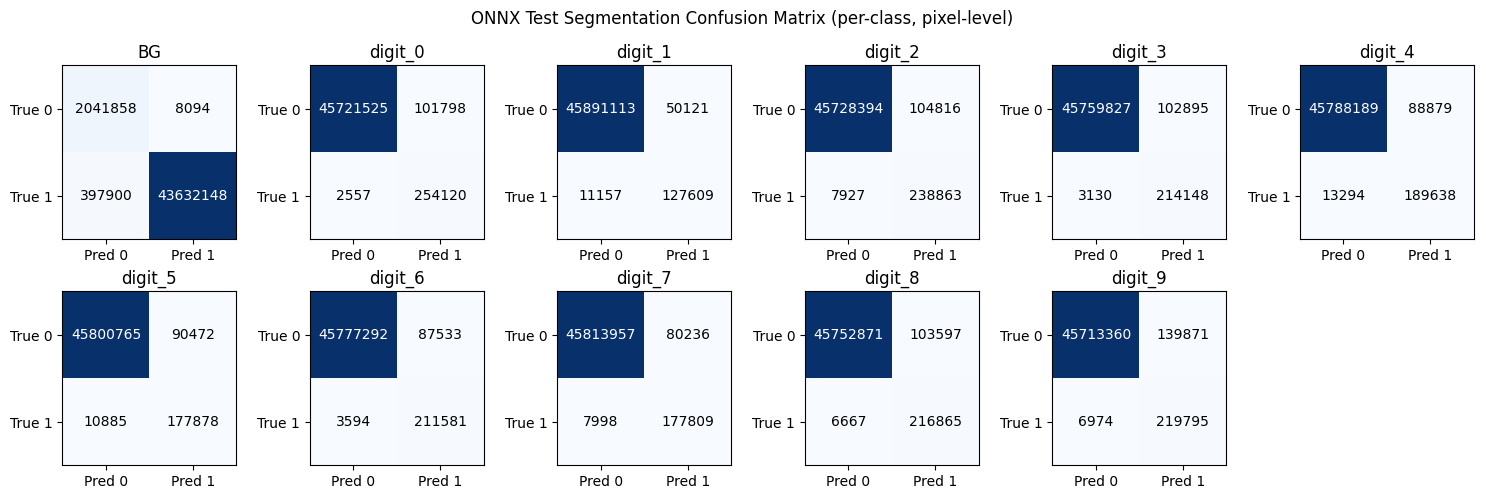


===== ONNX Runtime: Test 後処理評価 (画像中に存在する数字 multi-label) =====
Digit         F1   Precision    Recall      GT支持
digit_0     0.947       0.899     1.000       124
digit_1     0.934       0.888     0.985       137
digit_2     0.911       0.837     1.000       123
digit_3     0.881       0.787     1.000       118
digit_4     0.947       0.913     0.984       128
digit_5     0.907       0.842     0.982       114
digit_6     0.934       0.876     1.000       120
digit_7     0.903       0.823     1.000       121
digit_8     0.887       0.797     1.000       114
digit_9     0.880       0.795     0.985       134

Macro-F1 (presence, ONNX): 0.9131

----- ONNX 混同行列 (per-digit、画像単位) -----
Digit      TN   FP   FN   TP
digit_0    112   14    0  124
digit_1     96   17    2  135
digit_2    103   24    0  123
digit_3    100   32    0  118
digit_4    110   12    2  126
digit_5    115   21    2  112
digit_6    113   17    0  120
digit_7    103   26    0  121
digit_8    107   29    0  114
digit_9     82

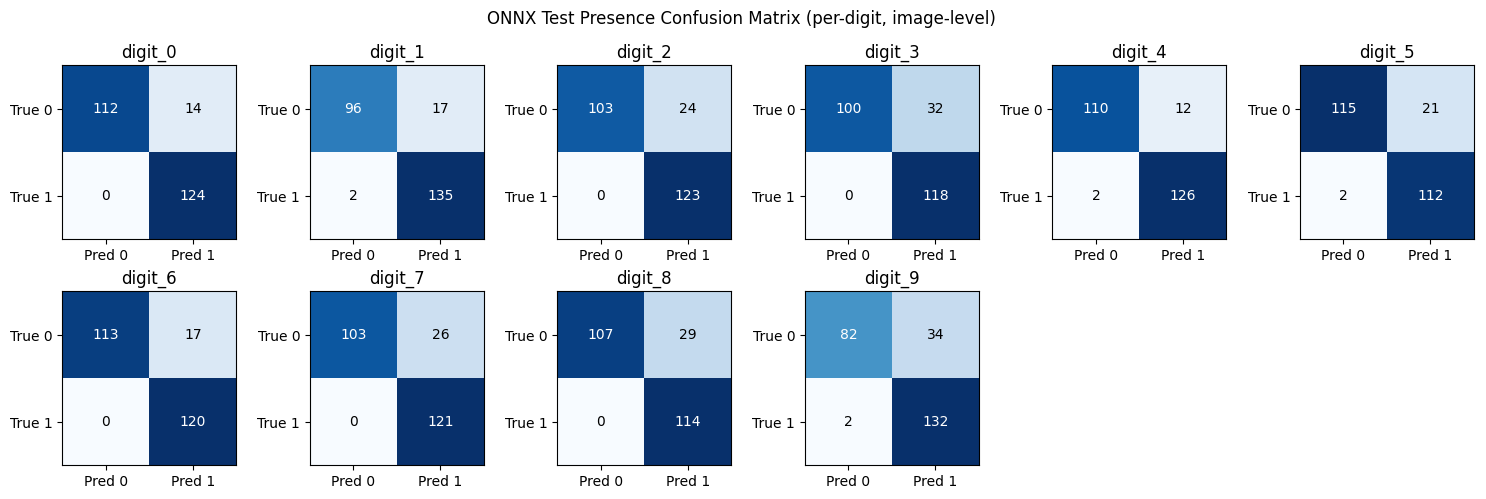


推論評価完了。出力先: saved_model/DeepLabV3_MNIST_segmentation_outputs


In [24]:
# ==================== ONNX 推論評価 (test_loader) ====================
print('===== ONNX Runtime: Test セグメンテーション評価 (per-class F1) =====')
print(f'{"Class":<10}{"F1":>8}{"Precision":>12}{"Recall":>10}')
for c in range(NUM_CLASSES):
    y_true_c = np.concatenate(onnx_all_gt[c])
    y_pred_c = np.concatenate(onnx_all_pred[c])
    f1_c = f1_score(y_true_c, y_pred_c, zero_division=0)
    precision_c = precision_score(y_true_c, y_pred_c, zero_division=0)
    recall_c = recall_score(y_true_c, y_pred_c, zero_division=0)
    print(f'{class_names[c]:<10}{f1_c:>8.3f}{precision_c:>12.3f}{recall_c:>10.3f}')

# ---------- 混同行列 (per-class、ピクセル単位) ----------
print('\n----- ONNX 混同行列 (per-class、ピクセル単位) -----')
print(f'{"Class":<10}{"TN":>12}{"FP":>10}{"FN":>10}{"TP":>10}')
confusion_matrices_onnx_seg = []
for c in range(NUM_CLASSES):
    y_true_c = np.concatenate(onnx_all_gt[c])
    y_pred_c = np.concatenate(onnx_all_pred[c])
    cm = confusion_matrix(y_true_c, y_pred_c, labels=[0, 1])
    confusion_matrices_onnx_seg.append(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f'{class_names[c]:<10}{tn:>12d}{fp:>10d}{fn:>10d}{tp:>10d}')

plot_confusion_matrices_grid(
    confusion_matrices_onnx_seg,
    class_names,
    title='ONNX Test Segmentation Confusion Matrix (per-class, pixel-level)',
    save_path=OUTPUT_VIS_DIR / f'{date_str}_confusion_matrix_onnx_segmentation.png',
)

# 後処理 multi-label 評価
gt_presence_array = np.stack(onnx_all_gt_presence, axis=0)
pred_presence_array = np.stack(onnx_all_pred_presence, axis=0)

print('\n===== ONNX Runtime: Test 後処理評価 (画像中に存在する数字 multi-label) =====')
print(f'{"Digit":<8}{"F1":>8}{"Precision":>12}{"Recall":>10}{"GT支持":>10}')
for digit_class in range(dg.NUM_DIGIT_CLASSES):
    y_true = gt_presence_array[:, digit_class]
    y_pred = pred_presence_array[:, digit_class]
    f1_d = f1_score(y_true, y_pred, zero_division=0)
    precision_d = precision_score(y_true, y_pred, zero_division=0)
    recall_d = recall_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())
    print(f'digit_{digit_class:<3}{f1_d:>8.3f}{precision_d:>12.3f}{recall_d:>10.3f}{support:>10d}')

macro_f1_onnx = f1_score(gt_presence_array, pred_presence_array, average='macro', zero_division=0)
print(f'\nMacro-F1 (presence, ONNX): {macro_f1_onnx:.4f}')

# ---------- 混同行列 (per-digit、画像単位) ----------
print('\n----- ONNX 混同行列 (per-digit、画像単位) -----')
print(f'{"Digit":<8}{"TN":>5}{"FP":>5}{"FN":>5}{"TP":>5}')
confusion_matrices_onnx_presence = []
for digit_class in range(dg.NUM_DIGIT_CLASSES):
    y_true = gt_presence_array[:, digit_class]
    y_pred = pred_presence_array[:, digit_class]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_matrices_onnx_presence.append(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f'digit_{digit_class:<3}{tn:>5d}{fp:>5d}{fn:>5d}{tp:>5d}')

digit_only_names = [f'digit_{i}' for i in range(dg.NUM_DIGIT_CLASSES)]
plot_confusion_matrices_grid(
    confusion_matrices_onnx_presence,
    digit_only_names,
    title='ONNX Test Presence Confusion Matrix (per-digit, image-level)',
    save_path=OUTPUT_VIS_DIR / f'{date_str}_confusion_matrix_onnx_presence.png',
)

print(f'\n推論評価完了。出力先: {OUTPUTS_DIR}')